# W11 gated single-cell distribution extension

## tl;dr

W8의 17개 완전 외부 cell line, 1,892개 24h single cell을 baseline PCA 10차원에
표현했다. Control cell 분포를 예측 pseudobulk Δ만큼 평행이동했을 때 B4는 B1보다
Energy distance를 0.571, sliced-Wasserstein을 0.163 줄였고 두 paired-bootstrap
CI가 모두 0 위였다. 사전 gate를 통과해 제한적 본문 결과로 승격한다. 그러나
이 방법은 분포의 평균 위치만 옮기고 shape/covariance를 예측하지 않으며 paired
cell trajectory를 복원하지 않는다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists() and (path / "cell_count_matrix.csv").exists()
)


In [2]:
gate = json.loads((root / "results/logs/distribution_gate.json").read_text())
validation = json.loads((root / "results/logs/distribution_validation.json").read_text())
summary = pd.read_csv(root / "results/tables/single_cell_distribution_summary.csv")
metrics = pd.read_csv(root / "results/tables/single_cell_distribution_metrics.csv")
scores = pd.read_parquet(root / "results/tables/single_cell_pca_scores.parquet")

display(pd.DataFrame({
    "metric": ["gate decision", "external lines", "single cells",
               "PCA variable genes", "PCA components"],
    "value": [gate["decision"], gate["external_lines"], gate["cells"],
              gate["pca_variable_genes"], gate["pca_components"]],
}))
assert validation["status"] == "passed"
assert gate["passed"] is True
assert gate["distribution_metric_used_for_tuning"] is False
assert gate["paired_cell_trajectory_claim"] is False


,metric,value
0,gate decision,promote_to_main_text
1,external lines,17
2,single cells,1892
3,PCA variable genes,2000
4,PCA components,10


## Context & Methods

### Key Assumptions

- 94-line 학습 cohort와 DepMap ID가 겹치지 않는 W8 external 17-line의 24h만 쓴다.
- 정상 `DMSO_24hr` control cells로 2,000 variable genes와 PCA 10축을 fit한다.
- 각 model의 고정 pseudobulk Δ를 PCA loading에 투영해 같은 line의 모든 control
  cell score에 동일하게 더한다.
- observed Tram cell score와 translated control score 사이의 multivariate Energy
  distance와 100개 고정 투영의 sliced-Wasserstein을 계산한다.
- distribution metric으로 모델·projection·유전자를 튜닝하지 않는다.
- 승격 gate는 B4−B1 paired gain의 95% CI lower bound가 두 metric 모두 0보다 큰지다.
- translation은 control covariance와 multimodality를 그대로 보존하므로 새로운
  세포상태 비율이나 cell-specific response를 생성하는 모델이 아니다.

## Results

,model,metric,macro_mean,ci95_low,ci95_high,gain_vs_b1,gain_ci95_low,gain_ci95_high,n_cell_lines
0,NO_CHANGE,energy_distance,12.407351,8.779062,16.332424,-5.189492,-6.579266,-3.683519,17
1,NO_CHANGE,sliced_wasserstein,5.006938,4.128403,5.967540,-1.247143,-1.535561,-0.887921,17
2,B1,energy_distance,7.217860,4.952650,9.734245,0.000000,0.000000,0.000000,17
3,B1,sliced_wasserstein,3.759795,3.086344,4.512024,0.000000,0.000000,0.000000,17
4,B4_FIXED_D20_A100,energy_distance,6.647262,4.537748,8.969072,0.570597,0.294577,0.904828,17
5,B4_FIXED_D20_A100,sliced_wasserstein,3.596755,2.953053,4.301090,0.163040,0.087361,0.245814,17
6,CCLR_FIXED_D20_R20_A100,energy_distance,6.627799,4.524854,8.935868,0.590060,0.308104,0.920156,17
7,CCLR_FIXED_D20_R20_A100,sliced_wasserstein,3.592879,2.954351,4.295851,0.166916,0.092084,0.251094,17


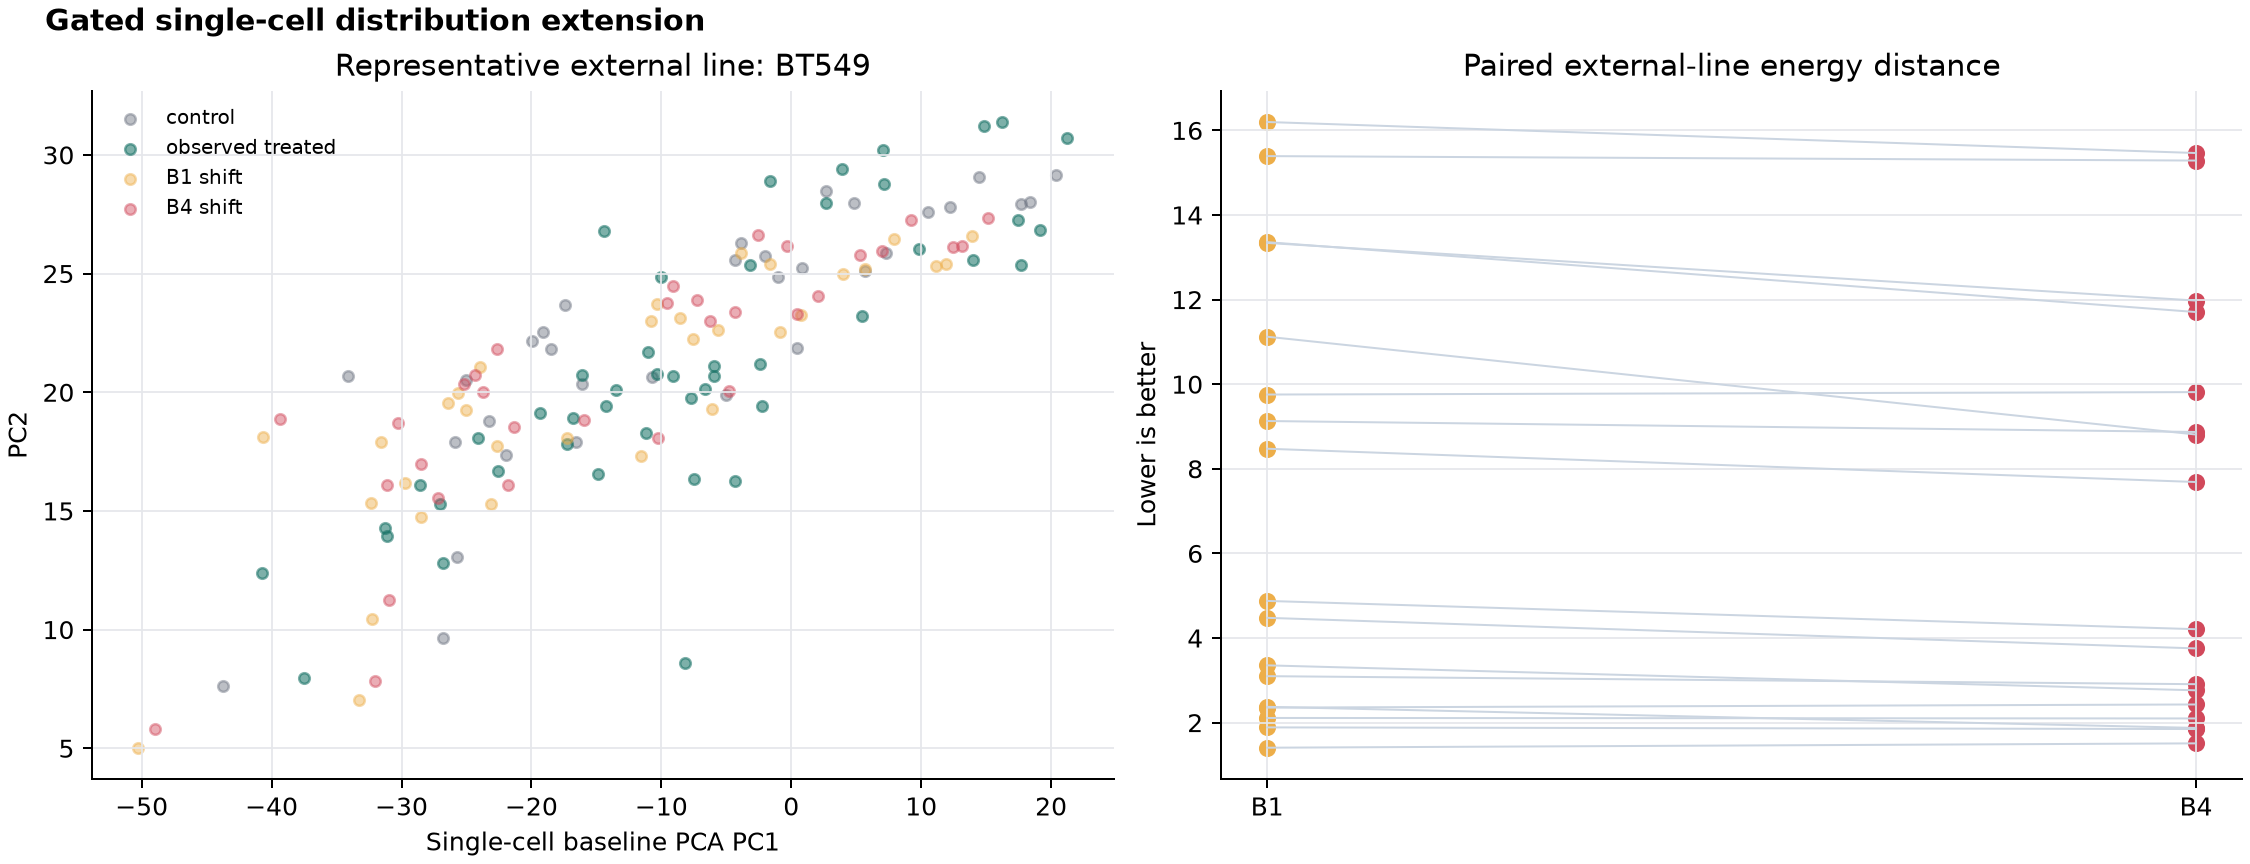

,energy_distance,sliced_wasserstein
model,,
B4_FIXED_D20_A100,4.207877,3.069897
CCLR_FIXED_D20_R20_A100,4.313694,3.081098
B1,4.876577,3.273284
NO_CHANGE,10.360622,4.701039


In [3]:
display(summary)
display(Image(filename=str(root / "results/figures/single_cell_distribution.png")))
display(metrics.groupby("model")[[
    "energy_distance", "sliced_wasserstein"
]].median().sort_values("energy_distance"))


## Takeaways

- No-change control 분포는 가장 멀고, B1 평균 이동이 큰 폭을 회수한다.
- B4는 B1보다 Energy 0.571 (95% CI 0.295–0.905), sliced-Wasserstein 0.163
  (0.087–0.246)을 추가 개선한다.
- 고정 CCLR도 비슷한 개선을 보이며 B4보다 수치상 아주 작게 낮지만, W11은
  distribution metric으로 두 모델을 새로 선택하는 단계가 아니다.
- 결과는 gene-wise RMSE의 작은 이득보다 latent distribution distance에서 더
  분명하지만, 이는 PCA가 response-relevant 평균 이동을 압축하기 때문일 수 있다.
- 본문에는 “external single-cell PCA에서 평균 translation이 개선됐다”로 포함하되,
  분포 shape 예측·paired trajectory·강한 개인화의 증거로 확장하지 않는다.